#### Źródło danych 

Po wstępnej analizie i pracy na danych publicznie dostępnych na OpenSky, w związku z bardzo restrykcyjnymi limitami nałożonymi przez OpenSky uniemożliwiającymi nam pobranie danych z wystarcząco długich okresów przez API (chcieliśmy pracować na okresie przynajmniej roku), poszukaliśmy publicznie dostępnych dużych zbiorów danych z OpenSky. Znaleźliśmy i wykorzystaliśmy zbiór danych (https://zenodo.org/records/7148117) lotniczych zebrany z OpenSky przez ludzi mających do nich nielimitowany dostęp, którzy publicznie udostępnili zbiór do pracy naukowej (zespół naukowców pracujących nad analizą trajektorii podczas odchodzenia samolotów na drugi krąg (https://www.mdpi.com/2673-4591/28/1/2)). Jest to po prostu bardzo duży (9 milionów wierszy, okres 10 lat) zbiór danych zawierający lądowania samolotów na prawie 180 lotniskach z 44 rónych krajów, umoliwiający znacznie dogłębniejszą, odpowiadającą na ciekawsze pytania analię. Dane pogodowe są z METAR.

#### Import bilbiotek i ustawienia wyświetlania wykresów

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time, datetime

#### Wczytanie danych

In [8]:
df = pd.read_csv('data/go_arounds_augmented.csv')
df.head()

/var/folders/w0/wdp641x524x0zzbtcx6zjsdh0000gn/T/ipykernel_9434/814013276.py:1: DtypeWarning: Columns (4,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/go_arounds_augmented.csv')


,time,icao24,callsign,airport,runway,has_ga,n_approaches,n_rwy_approached,registration,typecode,...,wind_gust_knts,visibility_m,temperature_deg,press_sea_level_p,press_p,weather_intensity,weather_precipitation,weather_desc,weather_obscuration,weather_other
0,2019-01-01 00:01:13+00:00,a3b110,AAY56,KAUS,18R,False,1,1,N337NV,A319,...,NaN,16093.44,10.0,1015.2,1014.901083,[],[],[],[],[]
1,2019-01-01 00:12:58+00:00,accee2,ASA1144,KAUS,18R,False,1,1,N924VA,NaN,...,NaN,16093.44,10.0,1015.2,1014.901083,[],[],[],[],[]
2,2019-01-01 00:13:54+00:00,a71ded,JBU511,KAUS,18L,False,1,1,N558JB,A320,...,NaN,16093.44,10.0,1015.2,1014.901083,[],[],[],[],[]
3,2019-01-01 00:20:21+00:00,a44031,DAL1475,KAUS,18L,False,1,1,N373NW,A320,...,NaN,16093.44,10.0,1015.2,1014.901083,[],[],[],[],[]
4,2019-01-01 00:27:41+00:00,a09cad,AAL2594,KAUS,18R,False,1,1,N139AN,A321,...,NaN,16093.44,10.0,1015.2,1014.901083,[],[],[],[],[]


#### Konwersja kolumny z czasem

In [ ]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# dodajemy godzinę, datę i miesiąc
df['hour']  = df['time'].dt.hour
df['date']  = df['time'].dt.date
df['month'] = df['time'].dt.month

#### Usunięcie wierszy z kluczowymi brakami

In [24]:
# usuńmy wiersze, które nie mają wartości w najistotniejszych dla nas kolumnach
df = df.dropna(subset=['time'])
df = df.dropna(subset=['visibility_m', 'wind_speed_knts'])
df = df.dropna(subset=['runway', 'icaoaircrafttype'])

# usuńmy duplikaty
df = df.drop_duplicates()

#### Ramka filtrująca loty z GA

In [11]:
df_ga = df[df['has_ga'] == 1]
df_ga.head()

,time,icao24,callsign,airport,runway,has_ga,n_approaches,n_rwy_approached,registration,typecode,...,press_sea_level_p,press_p,weather_intensity,weather_precipitation,weather_desc,weather_obscuration,weather_other,hour,date,month
303,2019-01-06 15:09:08+00:00,a1ed66,AAY1818,KAUS,18R,True,2,1,N223NV,A320,...,NaN,1020.319307,[''],['BC'],[''],['FG'],[None],15,2019-01-06,1
1549,2019-01-19 00:00:46+00:00,a37335,DAL761,KAUS,18L,True,2,1,N321NB,A319,...,1006.9,1007.112386,[''],[None],[''],['BR'],[None],0,2019-01-19,1
2259,2019-01-25 23:45:07+00:00,a3e9b2,DAL761,KAUS,18L,True,2,1,N351NB,A319,...,1023.0,1022.689780,[],[],[],[],[],23,2019-01-25,1
2547,2019-01-30 16:20:18+00:00,a8aaa5,GJS6294,KAUS,18R,True,2,1,N658CA,CRJ7,...,1026.1,1025.737531,[],[],[],[],[],16,2019-01-30,1
2957,2019-02-01 22:49:25+00:00,a92362,UAL701,KAUS,18R,True,2,1,N68802,B739,...,1018.3,1018.626112,[],[],[],[],[],22,2019-02-01,2


#### Rozkład go-aroundów w poszczególnych godzinach oraz miesiącach

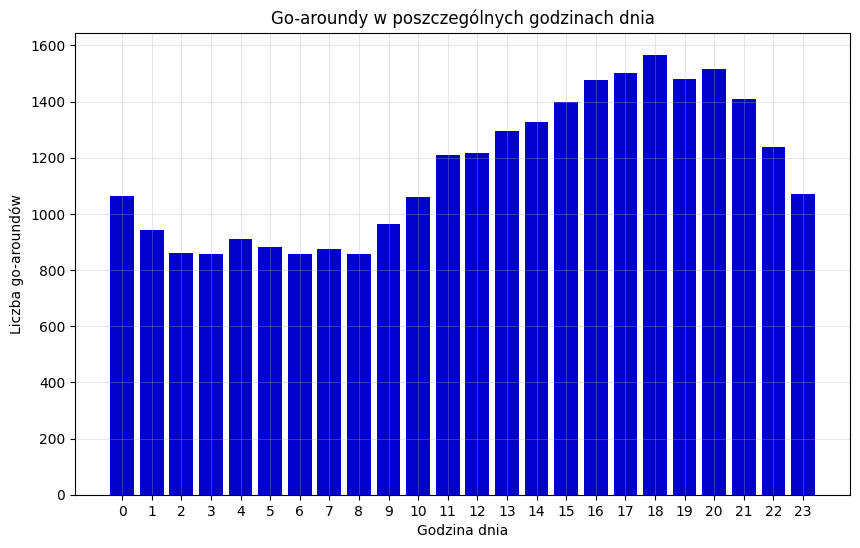

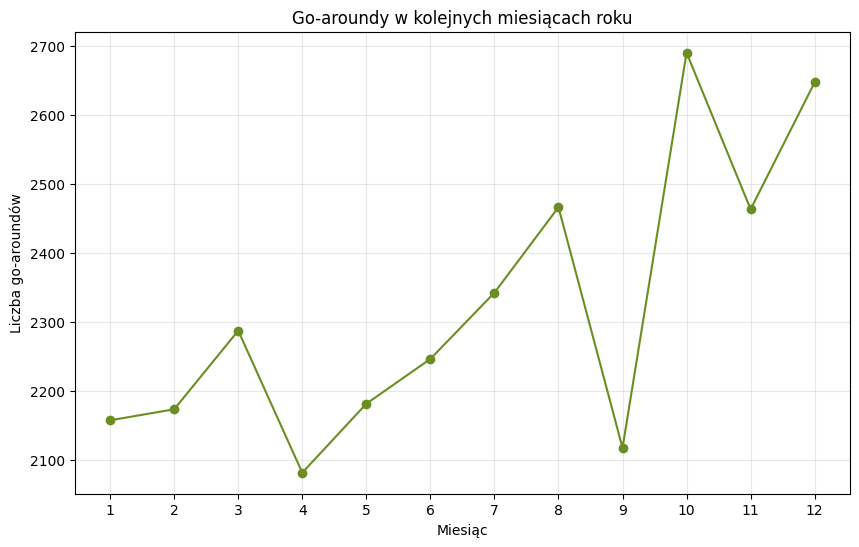

In [ ]:
# godziny
hourly_counts_ga = df_ga.groupby('hour').size().reset_index(name='ga_count')

plt.bar(hourly_counts_ga['hour'], hourly_counts_ga['ga_count'], color='mediumblue')
plt.xlabel('Godzina dnia')
plt.ylabel('Liczba go-aroundów')
plt.title('Go-aroundy w poszczególnych godzinach dnia')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

# miesiące
monthly_counts_ga = df_ga.groupby('month').size().reset_index(name='ga_count')

plt.plot(monthly_counts_ga['month'], monthly_counts_ga['ga_count'], marker='o', linestyle='-', color='olivedrab')
plt.xlabel('Miesiąc')
plt.ylabel('Liczba go-aroundów')
plt.title('Go-aroundy w kolejnych miesiącach roku')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

#### Najczęstsze typy statków powietrznych wykonujących go-aroundy

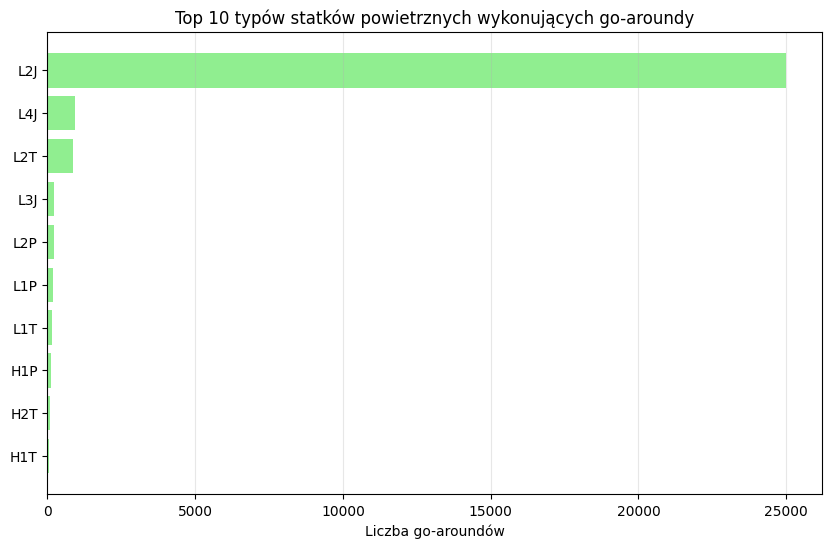

In [25]:
type_counts_ga = df_ga['icaoaircrafttype'].value_counts().reset_index()
type_counts_ga.columns = ['aircraft_type', 'ga_count']

# wybierzmy top 10
top10_types = type_counts_ga.head(10)

plt.barh(top10_types['aircraft_type'], top10_types['ga_count'], color='lightgreen')
plt.xlabel('Liczba go-aroundów')
plt.title('Top 10 typów statków powietrznych wykonujących go-aroundy')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.show()

#### Obliczmy ratio w relacji do ogólnej liczby lotów dla poprzednich 3 wykresów aby nadać większy kontekst

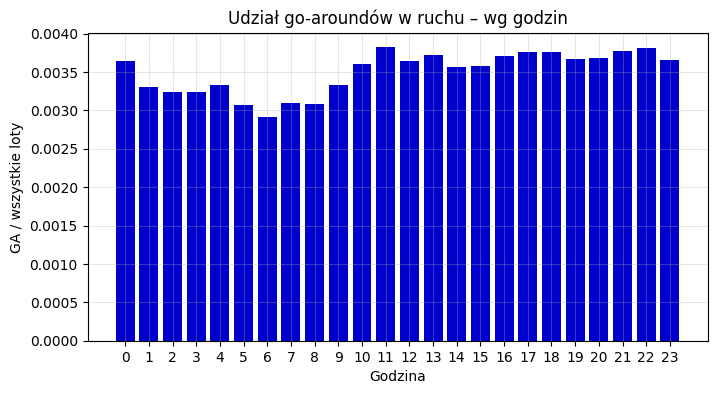

In [26]:
hour_all = df.groupby('hour').size().reset_index(name='total')
hour_ga = df_ga.groupby('hour').size().reset_index(name='ga')
hour_merged = hour_all.merge(hour_ga, on='hour', how='left').fillna(0)
hour_merged['ratio'] = hour_merged['ga'] / hour_merged['total']

plt.figure(figsize=(8,4))
plt.bar(hour_merged['hour'], hour_merged['ratio'], color='mediumblue')
plt.xlabel('Godzina')
plt.ylabel('GA / wszystkie loty')
plt.title('Udział go-aroundów w ruchu – wg godzin')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()

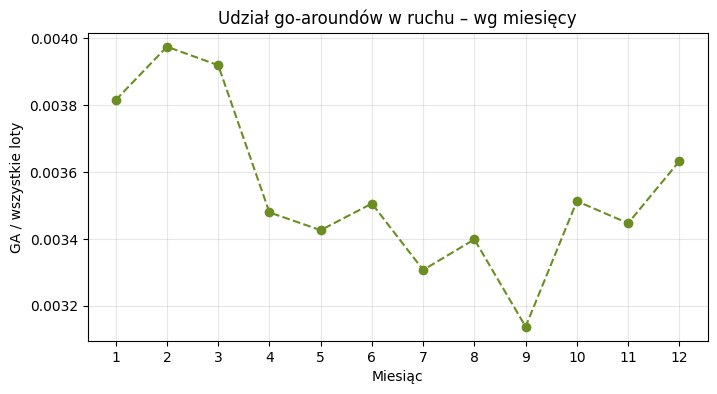

In [27]:
month_all = df.groupby('month').size().reset_index(name='total')
month_ga = df_ga.groupby('month').size().reset_index(name='ga')
month_merged = month_all.merge(month_ga, on='month', how='left').fillna(0)
month_merged['ratio'] = month_merged['ga'] / month_merged['total']

plt.figure(figsize=(8,4))
plt.plot(month_merged['month'], month_merged['ratio'], marker='o', linestyle='--', color='olivedrab')
plt.xlabel('Miesiąc')
plt.ylabel('GA / wszystkie loty')
plt.title('Udział go-aroundów w ruchu – wg miesięcy')
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.show()

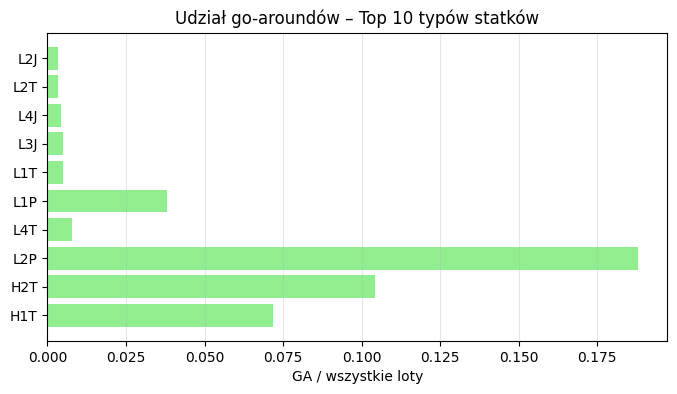

In [16]:
type_all = df['icaoaircrafttype'].value_counts().head(10).reset_index()
type_all.columns = ['aircraft_type', 'total']

type_ga  = df_ga['icaoaircrafttype'].value_counts().reset_index()
type_ga.columns = ['aircraft_type', 'ga']

type_merged = type_all.merge(type_ga, on='aircraft_type', how='left').fillna(0)
type_merged['ratio'] = type_merged['ga'] / type_merged['total']

plt.figure(figsize=(8,4))
plt.barh(type_merged['aircraft_type'], type_merged['ratio'], color='lightgreen')
plt.xlabel('GA / wszystkie loty')
plt.title('Udział go-aroundów – Top 10 typów statków')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.show()

#### Pierwsza analiza pogodowa: liczba i ratio go-aroundów według widzialności

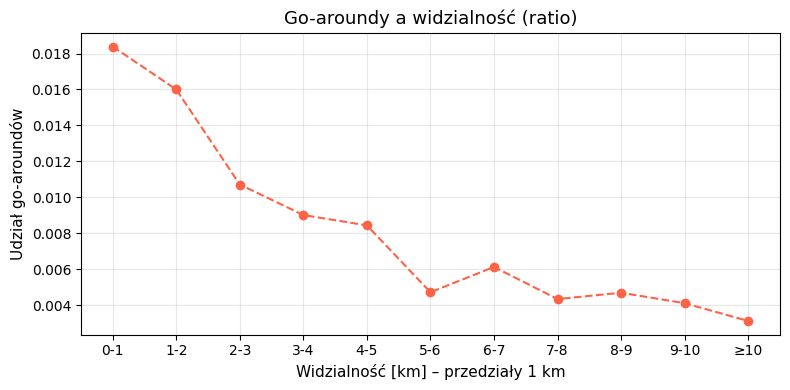

In [29]:
bins = list(range(0, 11000, 1000)) + [np.inf]
labels = [f"{b//1000}-{(b+1000)//1000}" for b in bins[:-2]] + ["≥10"]

df['vis_bin'] = pd.cut(df['visibility_m'], bins=bins, labels=labels, right=False)
df_ga['vis_bin'] = pd.cut(df_ga['visibility_m'], bins=bins, labels=labels, right=False)

total = df['vis_bin'].value_counts().sort_index()
ga = df_ga['vis_bin'].value_counts().sort_index()
ratio = (ga / total).fillna(0)

plt.figure(figsize=(8,4))
plt.plot(ratio.index, ratio.values, marker='o', linestyle='--', color='tomato')
plt.xlabel('Widzialność [km] – przedziały 1 km', fontsize=11)
plt.ylabel('Udział go-aroundów', fontsize=11)
plt.title('Go-aroundy a widzialność (ratio)', fontsize=13)
plt.xticks(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

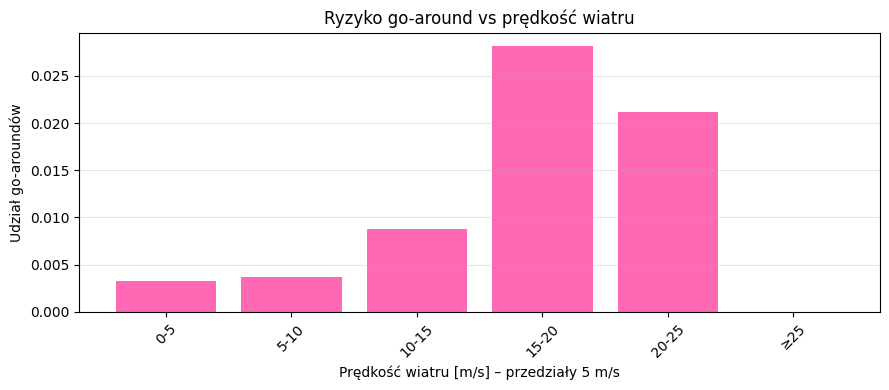

In [ ]:
# zmiana jednostki przy wietrze i ustalamy biny na 5 m/s
df['wind_ms'] = df['wind_speed_knts'] * 0.514 
df_ga['wind_ms'] = df_ga['wind_speed_knts'] * 0.514

bins = list(range(0, 25+5, 5)) + [np.inf]
labels = [f"{b}-{b+5}" for b in bins[:-2]] + ["≥25"]

df['wind_bin'] = pd.cut(df['wind_ms'], bins=bins, labels=labels, right=False)
df_ga['wind_bin'] = pd.cut(df_ga['wind_ms'], bins=bins, labels=labels, right=False)

total = df['wind_bin'].value_counts().sort_index()
ga = df_ga['wind_bin'].value_counts().sort_index()
ratio = (ga / total).fillna(0)

plt.figure(figsize=(9,4))
plt.bar(ratio.index, ratio.values, color='hotpink')
plt.xlabel('Prędkość wiatru [m/s] – przedziały 5 m/s')
plt.ylabel('Udział go-aroundów')
plt.title('Ryzyko go-around vs prędkość wiatru')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/w0/wdp641x524x0zzbtcx6zjsdh0000gn/T/ipykernel_9434/723547598.py:14: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(centers, ratio.values,


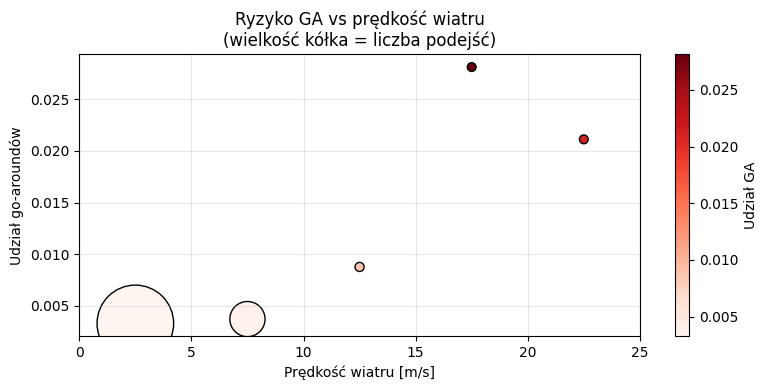

In [ ]:
step = 5
bins = list(range(0, 25+step, step)) + [np.inf]
labels = [f"{b}-{b+step}" for b in bins[:-2]] + ["≥20"]
centers= np.array([b+step/2 for b in bins[:-2]])

tot = df['wind_bin'].value_counts().sort_index()
ga = df_ga['wind_bin'].value_counts().sort_index()
ratio = (ga / tot).fillna(0).iloc[:-1]

# skalowanie bąbelków
p = tot.iloc[:-1] / tot.max()         
sizes = (p.pow(2) * 3000) + 40 

plt.figure(figsize=(8,4))
plt.scatter(centers, ratio.values,
            s=sizes, c=ratio.values, cmap='Reds',
            facecolors='none', edgecolors='black', linewidths=1)
plt.colorbar(label='Udział GA')
plt.xlim(0, 25)
plt.xlabel('Prędkość wiatru [m/s]')
plt.ylabel('Udział go-aroundów')
plt.title('Ryzyko GA vs prędkość wiatru\n(wielkość kółka = liczba podejść)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Na koniec zróbmy dashboard z modelem regresji predyktującym ryzyko GA na podstawie wiatru i widoczności

In [34]:
from sklearn.linear_model import LogisticRegression

# wybierzmy dane na input i etykietę
X = df[["wind_ms", "visibility_m"]]
y = df["has_ga"].astype(int)  

# najprostszy model
ga_model = LogisticRegression(max_iter=300, penalty=None)
ga_model.fit(X, y)


LogisticRegression(max_iter=300, penalty=None)

Mamy już, zróbmy teraz dashboard w formie widgetu w Jupyter Notebook

In [ ]:
from ipywidgets import interact, FloatSlider

def predict(wind_ms, visibility_m):
    proba = ga_model.predict_proba([[wind_ms, visibility_m]])[0, 1]
    return f"Szansa go-around: {proba*100:.5f}%"

interact(
    predict,
    wind_ms=FloatSlider(value=5.0, min=0.0, max=20.0, step=0.1,
                        description="Wiatr [m/s]"),
    visibility_m=FloatSlider(value=3000.0, min=0.0, max=5000.0, step=50.0,
                             description="Widoczność [m]")
)

interactive(children=(FloatSlider(value=5.0, description='Wiatr [m/s]', max=20.0), FloatSlider(value=3000.0, d…

<function __main__.predict(wind_ms, visibility_m)>